In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime

# 1. Data Collection

In [3]:
now = datetime.now()

start = datetime(now.year-10, now.month, now.day)
end = now
ticker = 'AAPL'
df = yf.download(ticker, start, end)
df

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2016-04-06,25.130268,25.134799,24.731662,24.964938,105616400
2016-04-07,24.582191,25.007974,24.487070,24.901528,127207600
2016-04-08,24.609364,24.860755,24.498387,24.665984,94326800
2016-04-11,24.690901,25.051006,24.647871,24.679578,117630000
2016-04-12,25.012505,25.026093,24.609370,24.763375,108929200
...,...,...,...,...,...
2026-03-27,248.800003,255.490005,248.070007,253.899994,47900000
2026-03-30,246.630005,250.869995,245.509995,250.070007,39446200


In [4]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2016-04-06,25.130268,25.134799,24.731662,24.964938,105616400
2016-04-07,24.582191,25.007974,24.487070,24.901528,127207600
2016-04-08,24.609364,24.860755,24.498387,24.665984,94326800
2016-04-11,24.690901,25.051006,24.647871,24.679578,117630000
2016-04-12,25.012505,25.026093,24.609370,24.763375,108929200


In [5]:
df.tail()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2026-03-27,248.800003,255.490005,248.070007,253.899994,47900000
2026-03-30,246.630005,250.869995,245.509995,250.070007,39446200
2026-03-31,253.789993,255.479996,247.100006,247.910004,49598100
2026-04-01,255.630005,256.179993,253.330002,254.080002,40059400
2026-04-02,255.919998,256.130005,250.649994,254.199997,31289400


# 2. Data Exploration & Visualiztion

In [6]:
df

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2016-04-06,25.130268,25.134799,24.731662,24.964938,105616400
2016-04-07,24.582191,25.007974,24.487070,24.901528,127207600
2016-04-08,24.609364,24.860755,24.498387,24.665984,94326800
2016-04-11,24.690901,25.051006,24.647871,24.679578,117630000
2016-04-12,25.012505,25.026093,24.609370,24.763375,108929200
...,...,...,...,...,...
2026-03-27,248.800003,255.490005,248.070007,253.899994,47900000
2026-03-30,246.630005,250.869995,245.509995,250.070007,39446200


In [7]:
type(df)

pandas.DataFrame

In [8]:
df.shape

(2513, 5)

In [9]:
df.isna().sum()

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

In [10]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,2513.000000,2513.000000,2513.000000,2513.000000,2.513000e+03
mean,120.172001,121.373018,118.864637,120.070668,9.836548e+07
std,75.220206,75.954133,74.435666,75.170773,5.591377e+07
min,20.584816,20.887868,20.386579,20.507344,1.791060e+07
25%,44.015903,44.336563,43.676229,44.048852,5.914450e+07
50%,126.366173,127.451658,124.349256,125.840197,8.644040e+07
75%,175.888351,177.608496,174.316729,175.618190,1.194232e+08
max,285.922455,288.350192,283.035157,285.932471,4.584084e+08


In [11]:
df.dtypes

Price   Ticker
Close   AAPL      float64
High    AAPL      float64
Low     AAPL      float64
Open    AAPL      float64
Volume  AAPL        int64
dtype: object

In [12]:
df = df.reset_index()

In [13]:
df.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
0,2016-04-06,25.130268,25.134799,24.731662,24.964938,105616400
1,2016-04-07,24.582191,25.007974,24.487070,24.901528,127207600
2,2016-04-08,24.609364,24.860755,24.498387,24.665984,94326800
3,2016-04-11,24.690901,25.051006,24.647871,24.679578,117630000
4,2016-04-12,25.012505,25.026093,24.609370,24.763375,108929200


Text(0, 0.5, 'Close Price')

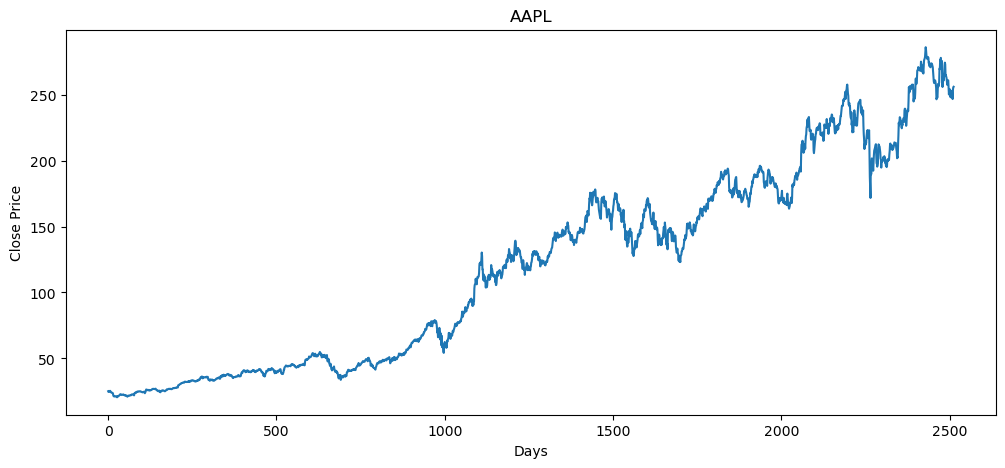

In [14]:
plt.figure(figsize=(12,5))
plt.plot(df.Close)
plt.title(ticker)
plt.xlabel('Days')
plt.ylabel('Close Price')

# 3. Feature Engineering

In [15]:
# 10,20,30,40,50,60,70,80,90,100
# MA of 5 days ==> null null null null 30 40

In [16]:
temp_df = [10,20,30,40,50,60,70,80,90,100]
print(sum(temp_df[:5])/5)

30.0


In [17]:
df1 = pd.DataFrame([10,20,30,40,50,60,70,80,90,100])
df1

,0
0,10
1,20
2,30
3,40
4,50
5,60
6,70
7,80
8,90
9,100


In [18]:
df1['MA_5'] = df1.rolling(5).mean()
df1

,0,MA_5
0,10,NaN
1,20,NaN
2,30,NaN
3,40,NaN
4,50,30.0
5,60,40.0
6,70,50.0
7,80,60.0
8,90,70.0
9,100,80.0


## 100 days Moving Averange

In [19]:
df['MA_100'] = df.Close.rolling(100).mean()
df.head(102)

Price,Date,Close,High,Low,Open,Volume,MA_100
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,
0,2016-04-06,25.130268,25.134799,24.731662,24.964938,105616400,NaN
1,2016-04-07,24.582191,25.007974,24.487070,24.901528,127207600,NaN
2,2016-04-08,24.609364,24.860755,24.498387,24.665984,94326800,NaN
3,2016-04-11,24.690901,25.051006,24.647871,24.679578,117630000,NaN
4,2016-04-12,25.012505,25.026093,24.609370,24.763375,108929200,NaN
...,...,...,...,...,...,...,...
97,2016-08-23,24.936859,25.044533,24.863549,24.877294,85030800,NaN
98,2016-08-24,24.748999,24.913946,24.668816,24.872709,94700400,NaN
99,2016-08-25,24.643614,24.714632,24.439721,24.602377,100344800,22.896334


Text(0, 0.5, 'Price')

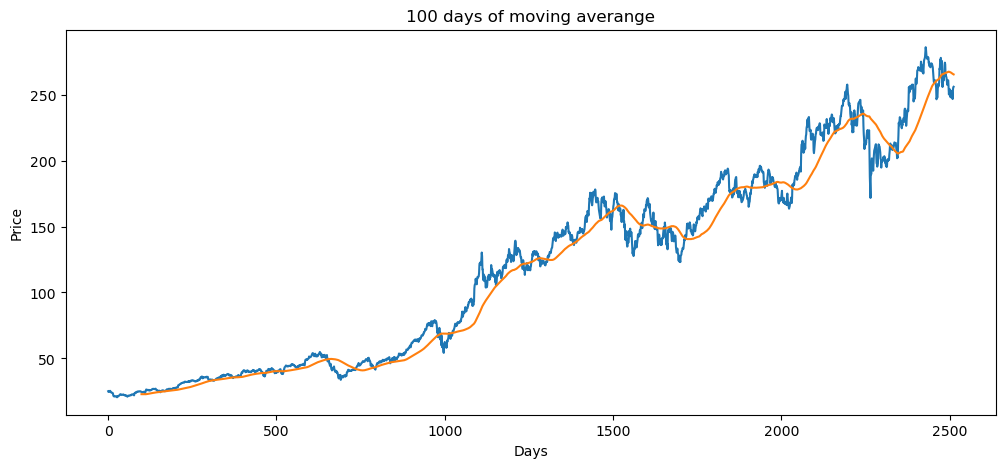

In [20]:
plt.figure(figsize=(12,5))
plt.plot(df.Close)
plt.plot(df['MA_100'])
plt.title('100 days of moving averange')
plt.xlabel('Days')
plt.ylabel('Price')

## 200 days Moving Averange

In [21]:
df['MA_200'] = df.Close.rolling(200).mean()
df.head(202)

Price,Date,Close,High,Low,Open,Volume,MA_100,MA_200
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,,
0,2016-04-06,25.130268,25.134799,24.731662,24.964938,105616400,NaN,NaN
1,2016-04-07,24.582191,25.007974,24.487070,24.901528,127207600,NaN,NaN
2,2016-04-08,24.609364,24.860755,24.498387,24.665984,94326800,NaN,NaN
3,2016-04-11,24.690901,25.051006,24.647871,24.679578,117630000,NaN,NaN
4,2016-04-12,25.012505,25.026093,24.609370,24.763375,108929200,NaN,NaN
...,...,...,...,...,...,...,...,...
197,2017-01-17,27.632397,27.687661,27.222516,27.250148,137759200,25.946153,NaN
198,2017-01-18,27.630091,27.747529,27.565615,27.632394,94852000,25.974964,NaN
199,2017-01-19,27.581736,27.653119,27.487326,27.494234,102389200,26.004346,24.450340


Text(0, 0.5, 'Price')

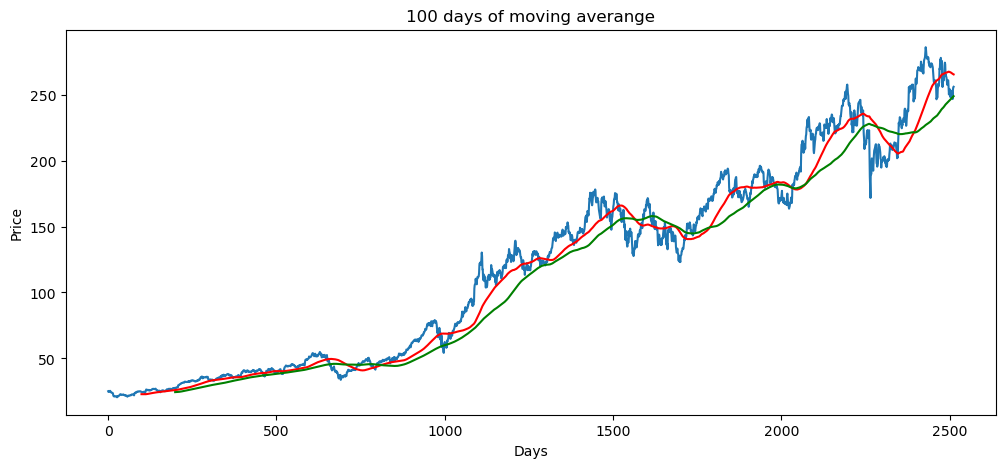

In [22]:
plt.figure(figsize=(12,5))
plt.plot(df.Close)
plt.plot(df['MA_100'], 'r')
plt.plot(df['MA_200'], 'g')
plt.title('100 days of moving averange')
plt.xlabel('Days')
plt.ylabel('Price')

## Calculating % changed in each trading session

In [23]:
df['Percentage Changed'] = df.Close.pct_change()
df[['Close','Percentage Changed']]

Price,Close,Percentage Changed
Ticker,AAPL,
0,25.130268,NaN
1,24.582191,-0.021809
2,24.609364,0.001105
3,24.690901,0.003313
4,25.012505,0.013025
...,...,...
2508,248.800003,-0.016173
2509,246.630005,-0.008722
2510,253.789993,0.029031


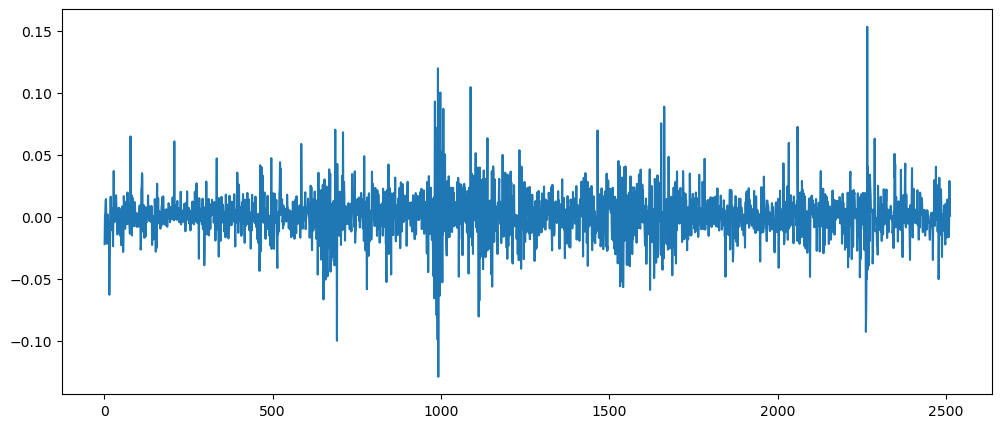

In [24]:
plt.figure(figsize=(12,5))
plt.plot(df['Percentage Changed'])

# 4. Data Preprocessing

In [25]:
# installed librabries for scikit-learn, keras, Tensoreflow
# Spliting data into 2 parts
# 1. 70% of data for data training
# 2. 30% of data for data testing

In [26]:
# Spliting data into Training & Testing datasets
data_training = pd.DataFrame(df.Close[0:int(len(df)*0.7)])
data_testing = pd.DataFrame(df.Close[int(len(df)*0.7):int(len(df))])
print(data_training)
print(data_testing)

Ticker        AAPL
0        25.130268
1        24.582191
2        24.609364
3        24.690901
4        25.012505
...            ...
1754    157.961594
1755    156.019714
1756    155.398712
1757    158.474152
1758    160.041473

[1759 rows x 1 columns]
Ticker        AAPL
1759    162.545166
1760    163.797058
1761    163.264755
1762    161.421448
1763    162.308640
...            ...
2508    248.800003
2509    246.630005
2510    253.789993
2511    255.630005
2512    255.919998

[754 rows x 1 columns]


In [27]:
# Scaling down the data between 0 & 1

In [28]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

In [29]:
data_training_array = scaler.fit_transform(data_training)
data_training_array

array([[0.02885656],
       [0.02537713],
       [0.02554963],
       ...,
       [0.85585888],
       [0.87538315],
       [0.88533321]], shape=(1759, 1))

In [30]:
type(data_training_array)

numpy.ndarray

In [31]:
data_training_array.shape

(1759, 1)

# 5. Sequence Creation

In [32]:
x_train = []
y_train = []
for i in range(100, data_training_array.shape[0]):
    x_train.append(data_training_array[i-100:i])
    y_train.append(data_training_array[i,0])

x_train, y_train = np.array(x_train), np.array(y_train)

In [33]:
x_train

array([[[0.02885656],
        [0.02537713],
        [0.02554963],
        ...,
        [0.02762872],
        [0.02643609],
        [0.02576706]],

       [[0.02537713],
        [0.02554963],
        [0.02606726],
        ...,
        [0.02643609],
        [0.02576706],
        [0.02485079]],

       [[0.02554963],
        [0.02606726],
        [0.02810895],
        ...,
        [0.02576706],
        [0.02485079],
        [0.02467628]],

       ...,

       [[0.80905836],
        [0.77400115],
        [0.73563827],
        ...,
        [0.86386894],
        [0.8721292 ],
        [0.85980128]],

       [[0.77400115],
        [0.73563827],
        [0.73395119],
        ...,
        [0.8721292 ],
        [0.85980128],
        [0.85585888]],

       [[0.73563827],
        [0.73395119],
        [0.73732525],
        ...,
        [0.85980128],
        [0.85585888],
        [0.87538315]]], shape=(1659, 100, 1))

In [34]:
y_train

array([0.02485079, 0.02467628, 0.02348366, ..., 0.85585888, 0.87538315,
       0.88533321], shape=(1659,))

In [35]:
x_train.ndim

3

In [36]:
y_train.ndim

1

In [37]:
x_train.shape

(1659, 100, 1)

In [38]:
y_train.shape

(1659,)

# 6. Model Building

In [39]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [40]:
# ML Model
from keras.models import Sequential
from keras.layers import Dense, LSTM, Input

In [41]:
model = Sequential()

model.add(Input(shape=(100, 1)))
model.add(LSTM(units=128, activation='tanh', return_sequences=True))
model.add(LSTM(units=64))
model.add(Dense(25))
model.add(Dense(1))

# 7. Model Training

In [42]:
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(x_train, y_train, epochs=50)

Epoch 1/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 9s 95ms/step - loss: 0.0134
Epoch 2/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - loss: 7.2894e-04
Epoch 3/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 6s 114ms/step - loss: 6.7310e-04
Epoch 4/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - loss: 6.5432e-04
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - loss: 6.6315e-04
Epoch 6/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 95ms/step - loss: 6.6606e-04
Epoch 7/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 103ms/step - loss: 6.9152e-04
Epoch 8/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 100ms/step - loss: 5.4641e-04
Epoch 9/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - loss: 6.1283e-04
Epoch 10/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - loss: 5.4831e-04
Epoch 11/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - loss: 4.8932e-04
Epoch 12/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - loss: 4.6890e-04
Epoch 13/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - loss: 4.9976e-04
Epoch 14/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 99ms/step - loss: 5.2244e-04
Epoch 15/50
5

In [43]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 100, 128)            │          66,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 25)                  │           1,625 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 352,859 (1.35 MB)

 Trainable params: 117,619 (459.45 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 235,240 (918.91 KB)

In [44]:
# Save The Trained Model
model.save('stock_prediction_model.keras')

# 8. Preparing Test Data

In [48]:
df

Price,Date,Close,High,Low,Open,Volume,MA_100,MA_200,Percentage Changed
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,,,
0,2016-04-06,25.130268,25.134799,24.731662,24.964938,105616400,NaN,NaN,NaN
1,2016-04-07,24.582191,25.007974,24.487070,24.901528,127207600,NaN,NaN,-0.021809
2,2016-04-08,24.609364,24.860755,24.498387,24.665984,94326800,NaN,NaN,0.001105
3,2016-04-11,24.690901,25.051006,24.647871,24.679578,117630000,NaN,NaN,0.003313
4,2016-04-12,25.012505,25.026093,24.609370,24.763375,108929200,NaN,NaN,0.013025
...,...,...,...,...,...,...,...,...,...
2508,2026-03-27,248.800003,255.490005,248.070007,253.899994,47900000,265.972003,247.696341,-0.016173
2509,2026-03-30,246.630005,250.869995,245.509995,250.070007,39446200,265.752922,247.938607,-0.008722
2510,2026-03-31,253.789993,255.479996,247.100006,247.910004,49598100,265.595559,248.214578,0.029031


In [49]:
data_training

Ticker,AAPL
0,25.130268
1,24.582191
2,24.609364
3,24.690901
4,25.012505
...,...
1754,157.961594
1755,156.019714
1756,155.398712
1757,158.474152


In [46]:
data_testing

Ticker,AAPL
1759,162.545166
1760,163.797058
1761,163.264755
1762,161.421448
1763,162.308640
...,...
2508,248.800003
2509,246.630005
2510,253.789993
2511,255.630005


In [50]:
past_100_days = data_training.tail(100)
past_100_days

Ticker,AAPL
1659,136.195953
1660,136.727432
1661,137.298248
1662,132.741364
1663,144.551941
...,...
1754,157.961594
1755,156.019714
1756,155.398712
1757,158.474152


In [52]:
final_df = pd.concat([past_100_days, data_testing], ignore_index=True) 
final_df

Ticker,AAPL
0,136.195953
1,136.727432
2,137.298248
3,132.741364
4,144.551941
...,...
849,248.800003
850,246.630005
851,253.789993
852,255.630005


In [53]:
input_data = scaler.fit_transform(final_df)
input_data

array([[8.07312891e-02],
       [8.39943848e-02],
       [8.74989970e-02],
       [5.95213074e-02],
       [1.32034150e-01],
       [1.49135166e-01],
       [1.40554586e-01],
       [1.51189555e-01],
       [1.43636216e-01],
       [1.55298802e-01],
       [1.58743176e-01],
       [1.38922991e-01],
       [1.52035519e-01],
       [1.57413898e-01],
       [1.39527157e-01],
       [1.16020895e-01],
       [9.75906950e-02],
       [1.39043656e-01],
       [1.40735676e-01],
       [1.37714472e-01],
       [1.30584021e-01],
       [1.08105094e-01],
       [9.62008979e-02],
       [1.06533738e-01],
       [1.03572959e-01],
       [1.17652490e-01],
       [1.23574328e-01],
       [1.09918060e-01],
       [6.93709268e-02],
       [5.73456916e-02],
       [4.44144417e-02],
       [4.39914600e-02],
       [6.30259196e-02],
       [4.35683846e-02],
       [4.13326239e-02],
       [3.02745789e-02],
       [6.16372935e-03],
       [2.77364542e-02],
       [2.96699445e-02],
       [3.02270344e-04],


In [54]:
input_data.shape

(854, 1)

In [56]:
x_test = []
y_test = []

for i in range(100, input_data.shape[0]):
    x_test.append(input_data[i-100:i])
    y_test.append(input_data[i,0])

x_test, y_test = np.array(x_test), np.array(y_test)

In [57]:
x_test

array([[[0.08073129],
        [0.08399438],
        [0.087499  ],
        ...,
        [0.19862956],
        [0.21751169],
        [0.2271345 ]],

       [[0.08399438],
        [0.087499  ],
        [0.05952131],
        ...,
        [0.21751169],
        [0.2271345 ],
        [0.2425063 ]],

       [[0.087499  ],
        [0.05952131],
        [0.13203415],
        ...,
        [0.2271345 ],
        [0.2425063 ],
        [0.25019248]],

       ...,

       [[0.89933315],
        [0.89994603],
        [0.89767851],
        ...,
        [0.7971922 ],
        [0.77208104],
        [0.75875801]],

       [[0.89994603],
        [0.89767851],
        [0.88971222],
        ...,
        [0.77208104],
        [0.75875801],
        [0.80271785]],

       [[0.89767851],
        [0.88971222],
        [0.89719567],
        ...,
        [0.75875801],
        [0.80271785],
        [0.81401488]]], shape=(754, 100, 1))

In [58]:
y_test

array([0.2425063 , 0.25019248, 0.24692433, 0.23560706, 0.24105411,
       0.22513716, 0.21769334, 0.21345706, 0.24650069, 0.24438269,
       0.24450354, 0.25200798, 0.25902835, 0.25309743, 0.24323263,
       0.24510883, 0.23566777, 0.23560706, 0.26374889, 0.2714346 ,
       0.2708902 , 0.26453564, 0.25793891, 0.24789264, 0.29497712,
       0.29455339, 0.28408339, 0.2949165 , 0.29606638, 0.29036975,
       0.28733956, 0.28733956, 0.29109702, 0.30539933, 0.30606608,
       0.30024795, 0.28424865, 0.28594545, 0.29291514, 0.30770217,
       0.31903518, 0.31873211, 0.33594349, 0.34115539, 0.33285286,
       0.33061036, 0.32218651, 0.33885255, 0.34121591, 0.35836676,
       0.35545779, 0.35933648, 0.37182096, 0.36521513, 0.36576028,
       0.3593971 , 0.37782065, 0.37588111, 0.36733604, 0.38424444,
       0.39145621, 0.39351687, 0.4200612 , 0.41091   , 0.40406172,
       0.40697088, 0.40012251, 0.3875778 , 0.38436576, 0.39460754,
       0.39927411, 0.40018322, 0.42018234, 0.41860658, 0.42690

In [59]:
x_test[0].shape

(100, 1)

# 9. Making Predictions

In [60]:
y_predicted = model.predict(x_test)

24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step


In [61]:
y_predicted

array([[0.21814792],
       [0.23102151],
       [0.24265257],
       [0.24744792],
       [0.24355628],
       [0.24185225],
       [0.2343384 ],
       [0.22583877],
       [0.21910743],
       [0.22985451],
       [0.23907381],
       [0.24418339],
       [0.24942653],
       [0.25536704],
       [0.25602728],
       [0.25083318],
       [0.24755473],
       [0.24194628],
       [0.23842457],
       [0.24936248],
       [0.26214373],
       [0.26946324],
       [0.26933956],
       [0.26460987],
       [0.2564715 ],
       [0.27270564],
       [0.28649062],
       [0.288651  ],
       [0.2925498 ],
       [0.29528975],
       [0.29374632],
       [0.29068196],
       [0.28879243],
       [0.28985703],
       [0.29789   ],
       [0.30386874],
       [0.3038439 ],
       [0.29499185],
       [0.28949738],
       [0.29047027],
       [0.29936707],
       [0.31119093],
       [0.3177935 ],
       [0.3286304 ],
       [0.33733022],
       [0.33696905],
       [0.33391514],
       [0.327

In [63]:
y_test

array([0.2425063 , 0.25019248, 0.24692433, 0.23560706, 0.24105411,
       0.22513716, 0.21769334, 0.21345706, 0.24650069, 0.24438269,
       0.24450354, 0.25200798, 0.25902835, 0.25309743, 0.24323263,
       0.24510883, 0.23566777, 0.23560706, 0.26374889, 0.2714346 ,
       0.2708902 , 0.26453564, 0.25793891, 0.24789264, 0.29497712,
       0.29455339, 0.28408339, 0.2949165 , 0.29606638, 0.29036975,
       0.28733956, 0.28733956, 0.29109702, 0.30539933, 0.30606608,
       0.30024795, 0.28424865, 0.28594545, 0.29291514, 0.30770217,
       0.31903518, 0.31873211, 0.33594349, 0.34115539, 0.33285286,
       0.33061036, 0.32218651, 0.33885255, 0.34121591, 0.35836676,
       0.35545779, 0.35933648, 0.37182096, 0.36521513, 0.36576028,
       0.3593971 , 0.37782065, 0.37588111, 0.36733604, 0.38424444,
       0.39145621, 0.39351687, 0.4200612 , 0.41091   , 0.40406172,
       0.40697088, 0.40012251, 0.3875778 , 0.38436576, 0.39460754,
       0.39927411, 0.40018322, 0.42018234, 0.41860658, 0.42690

In [64]:
y_predicted = scaler.inverse_transform(y_predicted.reshape(-1, 1)).flatten()
y_test = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

In [65]:
y_predicted

array([158.57777, 160.67458, 162.569  , 163.35004, 162.71617, 162.43864,
       161.21481, 159.83043, 158.73405, 160.4845 , 161.9861 , 162.81833,
       163.6723 , 164.63986, 164.74742, 163.90141, 163.36745, 162.45395,
       161.88036, 163.66187, 165.74362, 166.9358 , 166.91565, 166.14531,
       164.81976, 167.46391, 169.70915, 170.061  , 170.69604, 171.1423 ,
       170.89093, 170.3918 , 170.08406, 170.25745, 171.56583, 172.53961,
       172.53555, 171.09378, 170.19887, 170.35733, 171.8064 , 173.73222,
       174.80762, 176.5727 , 177.98967, 177.93085, 177.43344, 176.4031 ,
       177.15746, 178.06198, 179.99858, 180.90132, 181.48628, 182.74948,
       182.88858, 182.80899, 182.17905, 183.36508, 184.07454, 183.61937,
       184.67252, 186.03569, 186.91505, 189.59789, 190.27084, 189.63034,
       189.36583, 188.67421, 187.20067, 186.15361, 186.66249, 187.58763,
       188.19041, 190.2089 , 191.18198, 192.19283, 191.51425, 190.28592,
       190.08447, 190.63574, 191.51486, 191.27075, 

In [66]:
y_test

array([162.54516602, 163.79705811, 163.26475525, 161.42144775,
       162.30863953, 159.71615601, 158.5037384 , 157.81375122,
       163.195755  , 162.8507843 , 162.87046814, 164.09275818,
       165.23620605, 164.27020264, 162.66346741, 162.96905518,
       161.43133545, 161.42144775, 166.00506592, 167.25688171,
       167.16821289, 166.13320923, 165.0587616 , 163.42247009,
       171.09138489, 171.02236938, 169.31706238, 171.08151245,
       171.26879883, 170.34095764, 169.84741211, 169.84741211,
       170.45941162, 172.78890991, 172.89750671, 171.94987488,
       169.34397888, 169.62034607, 170.75553894, 173.16398621,
       175.00985718, 174.960495  , 177.7638092 , 178.61270142,
       177.26042175, 176.89517212, 175.52313232, 178.23762512,
       178.62255859, 181.41601562, 180.94221497, 181.57395935,
       183.6073761 , 182.53144836, 182.62023926, 181.58383179,
       184.58457947, 184.26867676, 182.87689209, 185.63085938,
       186.80548096, 187.14111328, 191.46453857, 189.97

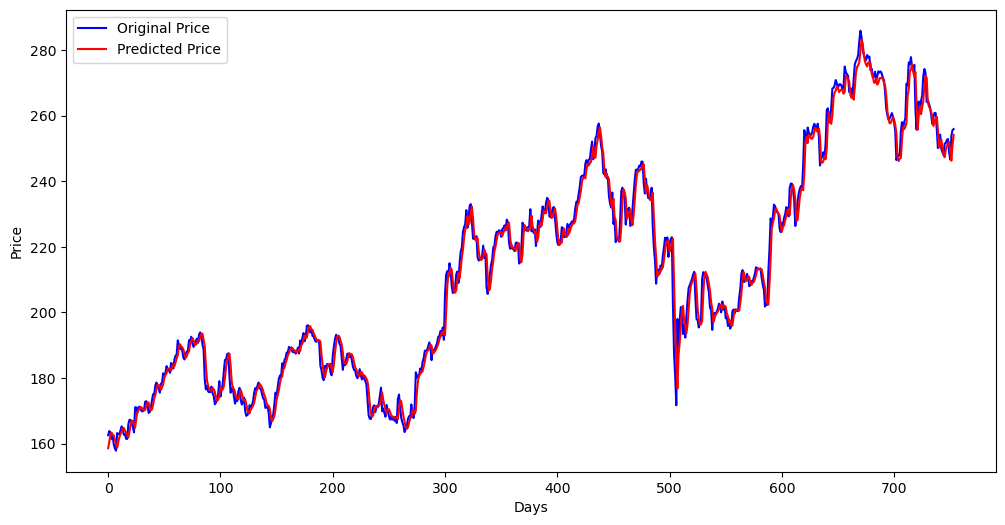

In [72]:
plt.figure(figsize=(12, 6))
plt.plot(y_test, 'b', label='Original Price')
plt.plot(y_predicted, 'r', label='Predicted Price')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()

(180.0, 280.0)

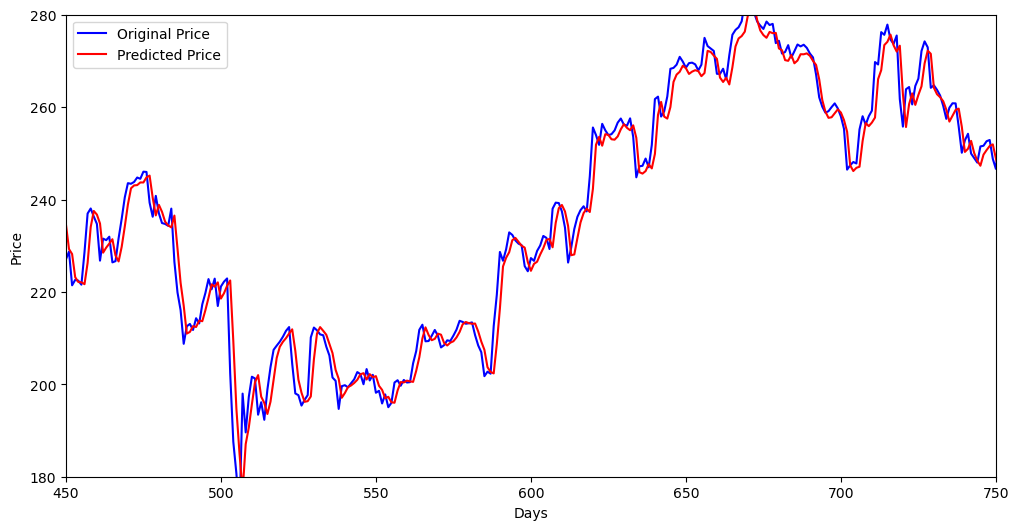

In [73]:
plt.figure(figsize=(12, 6))
plt.plot(y_test, 'b', label='Original Price')
plt.plot(y_predicted, 'r', label='Predicted Price')
plt.xlabel('Days')
plt.ylabel('Price')
plt.legend()
plt.xlim(450, 750)
plt.ylim(180, 280)

# 10. Model Evaluation

In [79]:
# Mean Squared Error (MSE)
from sklearn.metrics import mean_squared_error, r2_score

In [80]:
mse = mean_squared_error(y_test, y_predicted)
print(f'Mean Squared Error (MSE): {mse}')

Mean Squared Error (MSE): 13.882895388216799


In [81]:
# Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)
print(f'Root Mean Squared Error (MSE): {rmse}')

Root Mean Squared Error (MSE): 3.7259757632352897


In [82]:
# R-Squared
r2 = r2_score(y_test, y_predicted)
print(f'R-Squared: {r2}')

R-Squared: 0.9873201811055947
